In [47]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from helper_functions import plot_decision_boundary
from torchmetrics import Accuracy

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Exercises - I

(Date - 11/May/2026)

1. Make a binary classification dataset with Scikit-Learn's make_moons() function.
* For consistency, the dataset should have 1000 samples and a random_state=42.
* Turn the data into PyTorch tensors. Split the data into training and test sets using train_test_split with 80% training and 20% testing.

In [22]:
coords, labels = make_moons(n_samples=1000, noise=0.1, random_state=42)
coords.shape, labels.shape, coords[:10], labels[:10]

((1000, 2),
 (1000,),
 array([[-0.05146968,  0.44419863],
        [ 1.03201691, -0.41974116],
        [ 0.86789186, -0.25482711],
        [ 0.288851  , -0.44866862],
        [-0.83343911,  0.53505665],
        [ 0.61370557, -0.24236929],
        [ 0.2864947 , -0.20127661],
        [-0.05610416,  0.4770791 ],
        [ 1.60421687, -0.30354141],
        [ 0.70964149,  0.85886674]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0]))

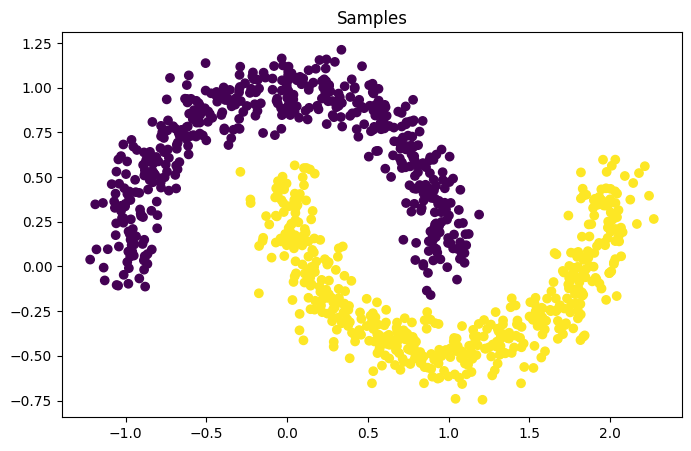

In [23]:
plt.figure(figsize=(8,5))
plt.title("Samples")
plt.scatter(coords[:, 0], coords[:, 1], c=labels)
plt.show()


In [24]:
coords = torch.from_numpy(coords).type(torch.float)
labels = torch.from_numpy(labels).type(torch.float)

In [25]:
train_coords, test_coords, train_labels, test_labels = train_test_split(coords, labels, train_size=0.8, random_state=42, shuffle=False)

train_coords.shape, train_labels.shape, test_coords.shape, test_labels.shape

(torch.Size([800, 2]),
 torch.Size([800]),
 torch.Size([200, 2]),
 torch.Size([200]))

In [26]:
train_coords.shape, train_labels.shape

(torch.Size([800, 2]), torch.Size([800]))

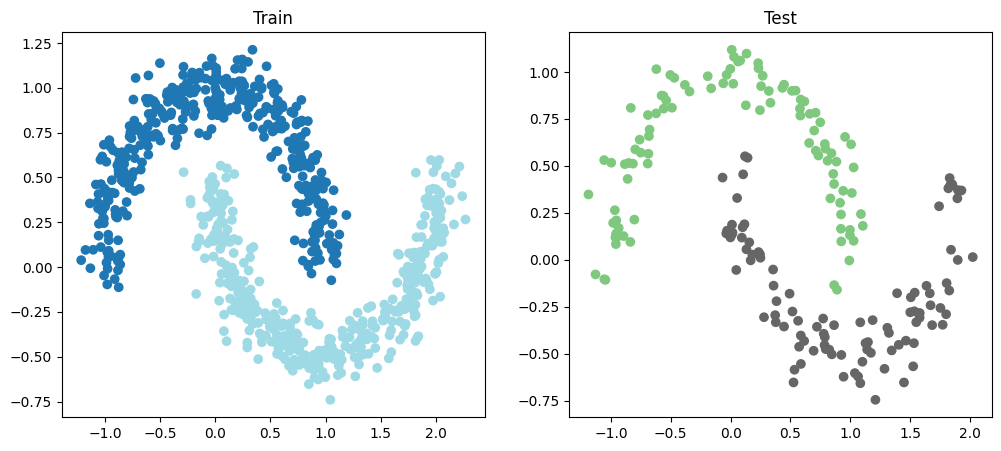

In [27]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Train")
plt.scatter(train_coords[:, 0], train_coords[:, 1], c=train_labels, cmap="tab20")
plt.subplot(1,2,2)
plt.title("Test")
plt.scatter(test_coords[:,0], test_coords[:, 1], c=test_labels, cmap="Accent")
plt.show()

(Date - 12/May/2026)

2. Build a model by subclassing nn.Module that incorporates non-linear activation functions and is capable of fitting the data you created in 1.
* Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [28]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(in_features=2, out_features=7),
            nn.ReLU(),
            nn.Tanh(),
            nn.Linear(in_features=7, out_features=7),
            nn.ReLU(),
            nn.Tanh(),
            nn.Linear(in_features=7, out_features=1)
        )

    def forward(self, x):
        return self.layer_stack(x)

model = Model()
model.state_dict()

OrderedDict([('layer_stack.0.weight',
              tensor([[-0.2883,  0.3622],
                      [ 0.4219, -0.0070],
                      [ 0.2868, -0.0172],
                      [-0.4826,  0.6510],
                      [-0.0761, -0.2341],
                      [-0.7012,  0.3520],
                      [-0.4214,  0.1192]])),
             ('layer_stack.0.bias',
              tensor([ 0.4772,  0.3316,  0.0906,  0.3738, -0.1778, -0.2452,  0.6803])),
             ('layer_stack.3.weight',
              tensor([[ 0.2960,  0.2865, -0.0777, -0.3458, -0.2197, -0.0501,  0.1899],
                      [-0.3105,  0.0129, -0.0164,  0.2932,  0.0190,  0.3571,  0.0736],
                      [-0.3276, -0.1402,  0.1265, -0.2920,  0.2383,  0.2898,  0.0354],
                      [-0.2207,  0.2962, -0.3435,  0.2907, -0.2693,  0.1642,  0.0881],
                      [ 0.1764,  0.1986,  0.1957, -0.1934,  0.3340,  0.3228, -0.0212],
                      [ 0.2771,  0.1275, -0.3056, -0.0690, -0.3470, 

3. Setup a binary classification compatible loss function and optimizer to use when training the model.

In [29]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model.parameters(),
                             lr = 0.1)

(Date - 13/May/2026)

4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.
* To measure model accuracy, you can create your own accuracy function or use the accuracy function in TorchMetrics.
* Train the model for long enough for it to reach over 96% accuracy.
* The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [ ]:
epochs = 3000

for epoch in range(epochs):
    model.train()

    train_logits = model(train_coords).squeeze()
    train_preds = torch.round(torch.sigmoid(train_logits))

    optimizer.zero_grad()
    train_loss = loss_fn(train_logits, train_labels)
    metric = Accuracy(task="binary", num_classes = 2)
    train_acc = metric(train_preds, train_labels) * 100

    
    train_loss.backward()

    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(test_coords).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, test_labels)
        test_acc = metric(test_preds, test_labels) * 100
    
    if epoch % 100 == 0:
        print(f"{epoch} | train loss : {train_loss} | train acc : {train_acc} | test loss : {test_loss} | test acc : {test_acc}")
    

0 | train loss : 0.00510751735419035 | train acc : 99.875 | test loss : 0.011882706545293331 | test acc : 99.0
100 | train loss : 0.005018650088459253 | train acc : 99.875 | test loss : 0.011803132481873035 | test acc : 99.0
200 | train loss : 0.004933255724608898 | train acc : 99.875 | test loss : 0.011718468740582466 | test acc : 99.0
300 | train loss : 0.004851137287914753 | train acc : 99.875 | test loss : 0.011636462062597275 | test acc : 99.0
400 | train loss : 0.0047722770832479 | train acc : 99.875 | test loss : 0.011554582044482231 | test acc : 99.0
500 | train loss : 0.0046965088695287704 | train acc : 99.875 | test loss : 0.011468874290585518 | test acc : 99.0
600 | train loss : 0.004623495042324066 | train acc : 99.875 | test loss : 0.011390757746994495 | test acc : 99.0
700 | train loss : 0.004553042817860842 | train acc : 99.875 | test loss : 0.011307014152407646 | test acc : 99.0
800 | train loss : 0.0044849589467048645 | train acc : 99.875 | test loss : 0.01122699398547

In [31]:
train_logits[:5], train_labels[:5]

(tensor([-1.0382,  4.1150,  3.4004,  3.8673, -3.9737], grad_fn=<SliceBackward0>),
 tensor([1., 1., 1., 1., 0.]))

In [32]:
test_logits.squeeze().shape

torch.Size([200])

In [33]:
model.eval()
with torch.inference_mode():
    test_logits = model(test_coords).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits.squeeze(), test_labels)
    test_acc = metric(test_preds, test_labels) * 100

print(f"Test Loss : {test_loss} | Test accuracy : {test_acc}")

Test Loss : 0.23245608806610107 | Test accuracy : 91.5


In [34]:
train_coords.shape, train_labels.shape

(torch.Size([800, 2]), torch.Size([800]))

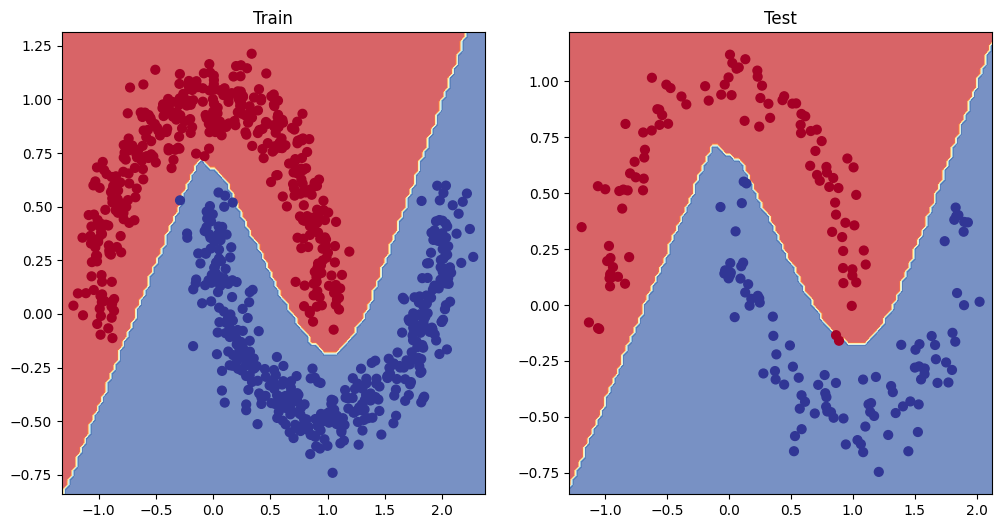

In [42]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model, train_coords, train_labels)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model, test_coords, test_labels)

(Date - 14/May/2026)

6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
* Feel free to reference the ML cheatsheet website for the formula.

In [43]:
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

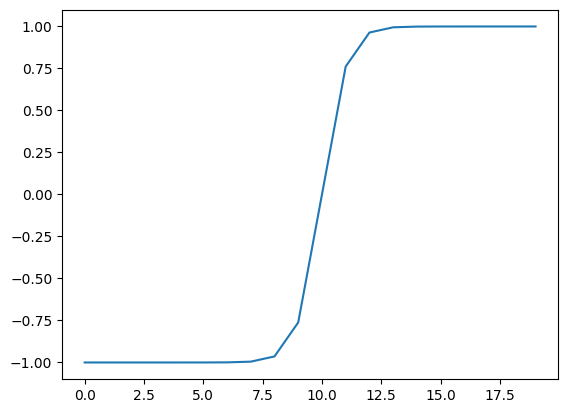

In [46]:
def Tanh(x):
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

plt.plot(Tanh(A))

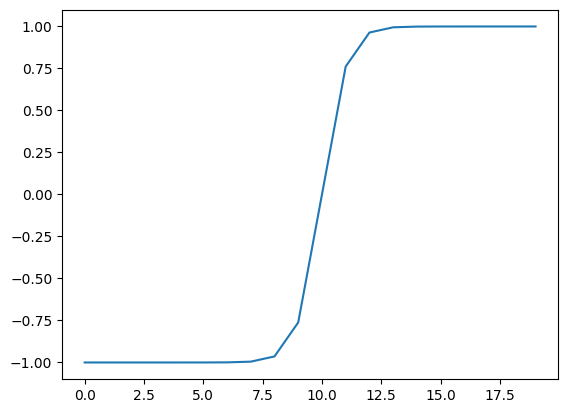

In [45]:
plt.plot(torch.tanh(A))

The next part of the exercise is in the next file (27.ipynb)